In [4]:
import torch
import torchvision.models as models

# Recreate the same model architecture
model = models.resnet18(pretrained=False)
model.fc = torch.nn.Linear(model.fc.in_features, 10)  # 10 CIFAR-10 classes

# Load the saved weights
model.load_state_dict(torch.load('cifar10_resnet18.pth'))
model.eval()

print("Model loaded! Ready to predict.")

/Users/kartik/Desktop/Local Projects/Machiene learning/venv/lib/python3.14/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/kartik/Desktop/Local Projects/Machiene learning/venv/lib/python3.14/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded! Ready to predict.


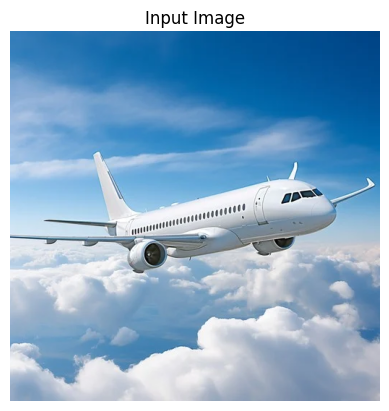

Predicted: airplane


In [7]:
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

classes = ['airplane', 'car', 'bird', 'cat', 'deer', 
           'dog', 'frog', 'horse', 'ship', 'truck']

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

img = Image.open('C.jpg')
img_tensor = transform(img).unsqueeze(0)

plt.imshow(img)
plt.title("Input Image")
plt.axis('off')
plt.show()

with torch.no_grad():
    output = model(img_tensor)
    _, predicted = torch.max(output, 1)
    print(f"Predicted: {classes[predicted[0]]}")